In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib import colors
from skimage.feature import peak_local_max
from scipy.signal import find_peaks

In [46]:
img = cv2.imread('Picture3.jpg')
img_greyscale = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

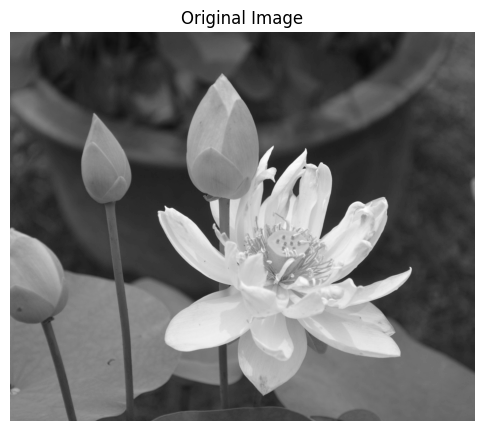

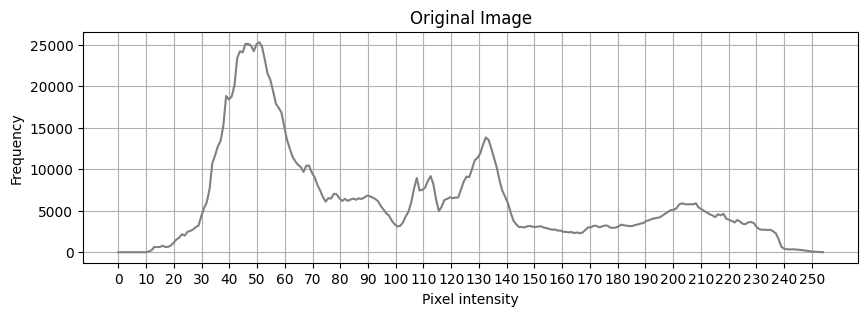

In [72]:
plt.figure(figsize=(6, 6))
plt.imshow(img_greyscale, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')
plt.show()

hist, bins = np.histogram(img_greyscale.ravel(), bins=256, range=(0, 255))

# Plot as a line instead of bars
plt.figure(figsize=(10, 3))
plt.plot(bins[:-1], hist, color='gray')
plt.title("Original Image")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")

plt.xticks(np.arange(0, 256, 10))  
plt.grid()
plt.show()

In [48]:
def histogram_equalization(img):

    # cdf of image
    hist,bins = np.histogram(img.flatten(),256,[0,256])
 
    cdf = hist.cumsum()

    sk = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min()) 
    sk = sk.astype(np.uint8)
    
    new_img = sk[img]
    return new_img

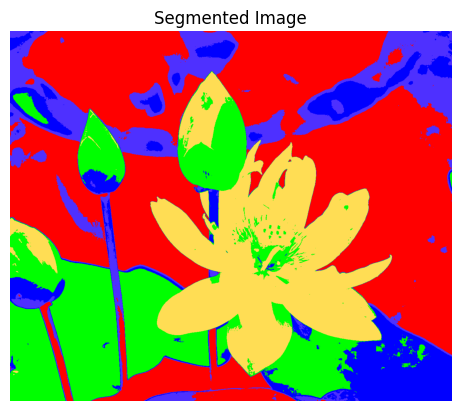

In [49]:
region1 = img_greyscale < 68
region5 = (img_greyscale >= 68) & (img_greyscale < 91)
region2 = (img_greyscale >= 91) & (img_greyscale < 115)
region3 = (img_greyscale >= 115) & (img_greyscale < 163)
region4 = img_greyscale >= 163


h, w = img_greyscale.shape
segmented = np.zeros((h, w, 3), dtype=np.uint8)

segmented[region1] = (255, 0, 0)  
segmented[region2] = (0, 0, 255)     
segmented[region3] = (0, 255, 0)    
segmented[region4] = (255, 221, 84)   
segmented[region5] = (78, 48, 255)

plt.imshow(segmented)
plt.title("Segmented Image")
plt.axis("off")
plt.show()


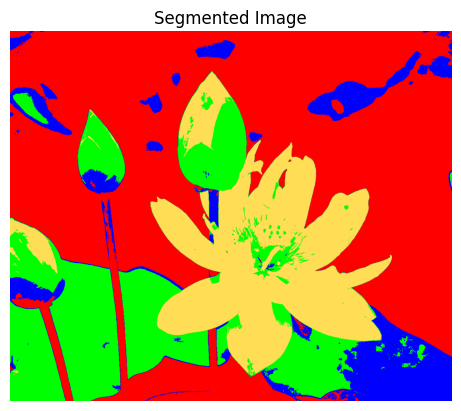

In [50]:
region1 = img_greyscale < 91
#region5 = (img_greyscale >= 68) & (img_greyscale < 91)
region2 = (img_greyscale >= 91) & (img_greyscale < 115)
region3 = (img_greyscale >= 115) & (img_greyscale < 163)
region4 = img_greyscale >= 163


h, w = img_greyscale.shape
segmented = np.zeros((h, w, 3), dtype=np.uint8)

segmented[region1] = (255, 0, 0)  
segmented[region2] = (0, 0, 255)     
segmented[region3] = (0, 255, 0)    
segmented[region4] = (255, 221, 84)   
#segmented[region5] = (78, 48, 255)

plt.imshow(segmented)
plt.title("Segmented Image")
plt.axis("off")
plt.show()


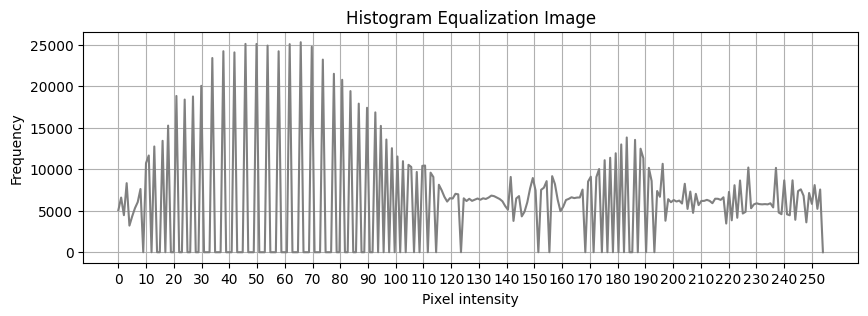

In [51]:
img_histo = histogram_equalization(img_greyscale)

hist, bins = np.histogram(img_histo.ravel(), bins=256, range=(0, 255))

# Plot as a line instead of bars
plt.figure(figsize=(10, 3))
plt.plot(bins[:-1], hist, color='gray')
plt.title("Histogram Equalization Image")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")

plt.xticks(np.arange(0, 256, 10))  
plt.grid()
plt.show()

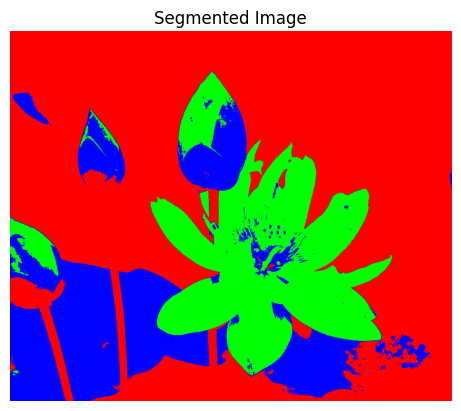

In [52]:
region1 = img_greyscale < 114
#region5 = (img_greyscale >= 200) & (img_greyscale < 218)
region2 = (img_greyscale >= 114) & (img_greyscale < 158)
region3 = (img_greyscale >= 158) & (img_greyscale < 256)
#region4 = img_greyscale >= 218


h, w = img_greyscale.shape
segmented = np.zeros((h, w, 3), dtype=np.uint8)

segmented[region1] = (255, 0, 0)  
segmented[region2] = (0, 0, 255)     
segmented[region3] = (0, 255, 0)    
#segmented[region4] = (255, 221, 84)   
#segmented[region5] = (78, 48, 255)

plt.imshow(segmented)
plt.title("Segmented Image")
plt.axis("off")
plt.show()

## Question 2

In [69]:
def global_iterative(img, tol=0.5):
    img = img.astype(np.float32)
    t = 0.5 * (np.min(img) + np.max(img))
    while True:
        g1 = img >= t
        g2 = img <= t

        new_t = (np.mean(img[g1]) + np.mean(img[g2]))/2

        if abs(t - new_t) < tol:
            break

        t = new_t

    binary_image = img >= t
    return binary_image, t

def biLevel(img, T):
    return np.where(img <= T, 0, 255).astype(np.uint8)

def trilevel(img, T1, T2):
    segmented = np.zeros_like(img, dtype=np.uint8)
    segmented[img <= T1] = 0
    segmented[(img > T1) & (img <= T2)] = 128
    segmented[img > T2] = 255
    
    return segmented

def multilevel(img):
    # Compute histogram
    hist, bins = np.histogram(img, bins=256, range=(0, 255))
    
    # Find local minima
    # Since find_peaks finds maxima, invert the histogram to find minima
    minima_indices, _ = find_peaks(-hist)
    
    # Get the corresponding intensity values
    minima_values = bins[minima_indices]
    
    print(minima_values.tolist())


def local_adaptive(img, window_size=15, weight=1.0):
    # sliding window
    # calculate local mean of the window
    # if the pixel values are uniformed, make 0 or 1 based on local mean
    # if pixel greater than threshold, pixel = 1, else pixel = 0
    # threshold = weight * [local_mean + (local max pixel - local minimum pixel)/global max pixel]
    half = window_size // 2
    h, w = img.shape
    output = np.zeros_like(img, dtype=np.uint8)

    global_max = np.max(img)

    # Pad image to handle edges
    padded = np.pad(img, pad_width=half, mode='reflect')

    for i in range(h):
        for j in range(w):
            # Extract local window
            local_window = padded[i:i+window_size, j:j+window_size]
            local_mean = np.mean(local_window)
            local_max = np.max(local_window)
            local_min = np.min(local_window)

            # Calculate adaptive threshold
            threshold = weight * (local_mean + (local_max - local_min) / (global_max + 1e-8))

            # Apply threshold
            if img[i, j] > threshold:
                output[i, j] = 1
            else:
                output[i, j] = 0

    return output        


def Niblack(img, window_size=15, weight=-0.2):
    img = np.asarray(img)
    
    # Convert RGB → grayscale if needed
    if img.ndim == 3 and img.shape[2] == 3:
        img = np.mean(img, axis=2)  # simple luminance average
    elif img.ndim == 2:
        pass
    else:
        raise ValueError("Unsupported image shape")

    h, w = img.shape
    half = window_size // 2
    output = np.zeros_like(img, dtype=np.uint8)

    padded = np.pad(img, ((half, half), (half, half)), mode='reflect')
    
    for i in range(h):
        for j in range(w):
            local_window = padded[i:i+window_size, j:j+window_size]
            local_mean = np.mean(local_window)
            local_std = np.std(local_window)
            threshold = local_mean + (weight*local_std)
            output[i, j] = 255 if img[i, j] > threshold else 0

    return output

def Sauvola(img, window_size=15, weight=-0.2, R=128):
    img = np.asarray(img)
    
    # Convert RGB → grayscale if needed
    if img.ndim == 3 and img.shape[2] == 3:
        img = np.mean(img, axis=2)  # simple luminance average
    elif img.ndim == 2:
        pass
    else:
        raise ValueError("Unsupported image shape")

    h, w = img.shape
    half = window_size // 2
    output = np.zeros_like(img, dtype=np.uint8)

    padded = np.pad(img, ((half, half), (half, half)), mode='reflect')
    
    for i in range(h):
        for j in range(w):
            local_window = padded[i:i+window_size, j:j+window_size]
            local_mean = np.mean(local_window)
            local_std = np.std(local_window)
            threshold = local_mean * (1 + weight * (local_std / R - 1))
            output[i, j] = 255 if img[i, j] > threshold else 0

    return output


def adaptive_gaussian(img, window_size=15, weight=1.0):
    half = window_size // 2
    h, w = img.shape
    output = np.zeros_like(img, dtype=np.uint8)

    # Pad the image to handle edges
    padded = np.pad(img, pad_width=half, mode='reflect')

    # Precompute Gaussian kernel
    gk_1d = cv2.getGaussianKernel(window_size, -1)  # sigma=-1 uses default
    gaussian_kernel = np.outer(gk_1d, gk_1d)

    for i in range(h):
        for j in range(w):
            # Extract local window
            window = padded[i:i+window_size, j:j+window_size]
            
            # Weighted mean using Gaussian kernel
            local_mean = np.sum(window * gaussian_kernel)
            
            # Adaptive threshold
            threshold = local_mean * weight
            
            output[i, j] = 255 if img[i, j] > threshold else 0

    return output    

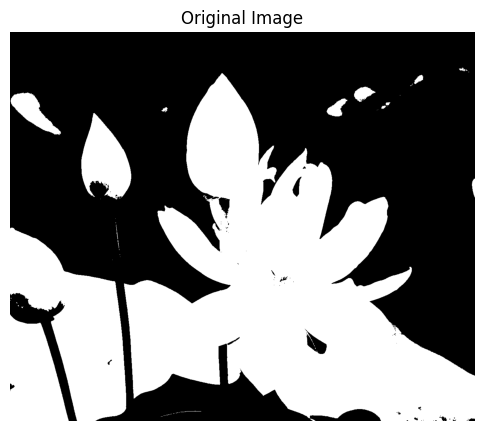

In [54]:
img_new = biLevel(img_greyscale, 102)

plt.figure(figsize=(6, 6))
plt.imshow(img_new, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')
plt.show()

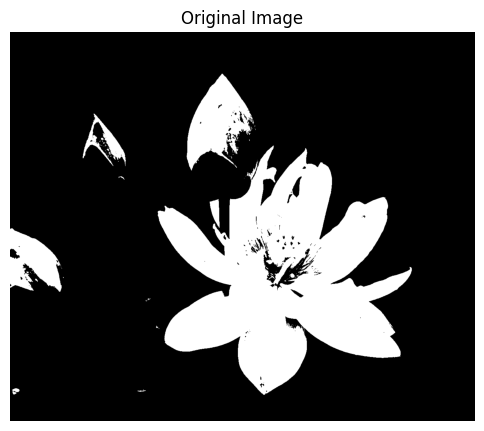

In [55]:
img_new = biLevel(img_greyscale, 150)

plt.figure(figsize=(6, 6))
plt.imshow(img_new, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')
plt.show()

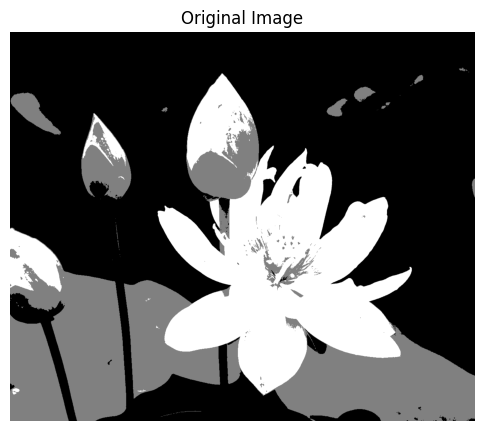

In [56]:
img_new = trilevel(img_greyscale, 102, 150)

plt.figure(figsize=(6, 6))
plt.imshow(img_new, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')
plt.show()

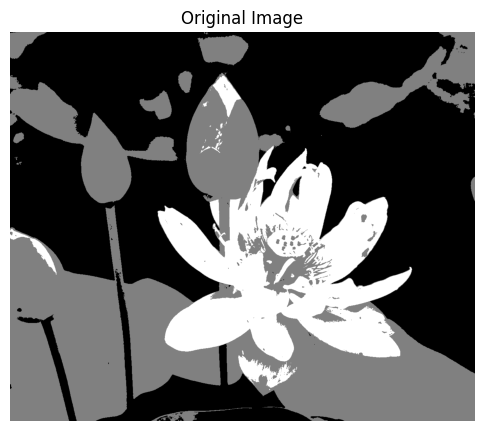

In [57]:
img_new = trilevel(img_greyscale, 80, 180)

plt.figure(figsize=(6, 6))
plt.imshow(img_new, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')
plt.show()

115.00265502929688


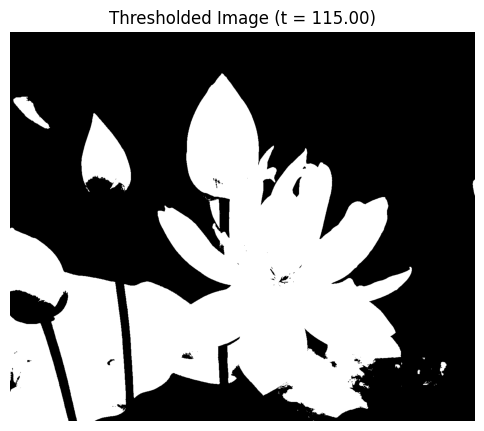

In [58]:
img_new, t = global_iterative(img_greyscale)

print(t)

plt.figure(figsize=(6, 6))
plt.imshow(img_new, cmap='gray', vmin=0, vmax=1)
plt.title(f"Thresholded Image (t = {t:.2f})")
plt.axis('off')
plt.show()


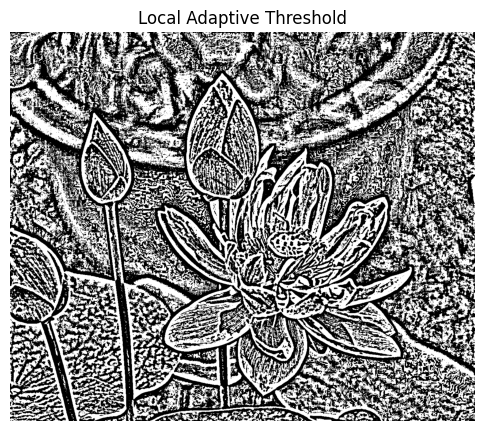

In [59]:
img_new = local_adaptive(img_greyscale)

plt.figure(figsize=(6, 6))
plt.imshow(img_new, cmap='gray', vmin=0, vmax=1)
plt.title(f"Local Adaptive Threshold")
plt.axis('off')
plt.show()

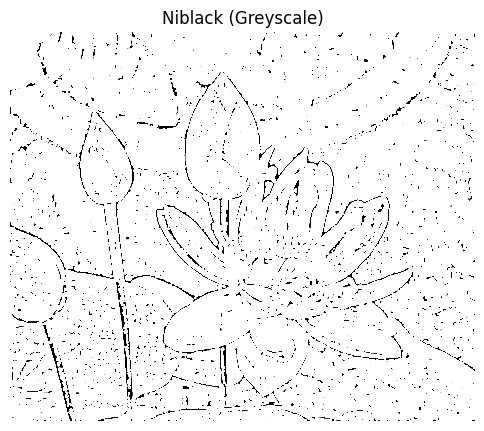

In [67]:
img_new = Niblack(img_greyscale)

plt.figure(figsize=(6, 6))
plt.imshow(img_new, cmap='gray', vmin=0, vmax=1)
plt.title(f"Niblack (Greyscale)")
plt.axis('off')
plt.show()

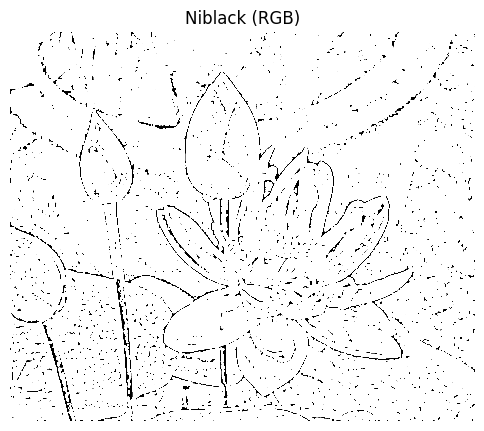

In [68]:
img_new = Niblack(img)

plt.figure(figsize=(6, 6))
plt.imshow(img_new, cmap='gray', vmin=0, vmax=1)
plt.title(f"Niblack (RGB)")
plt.axis('off')
plt.show()

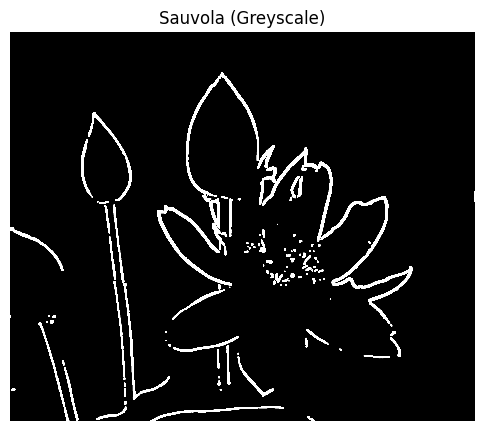

In [62]:
img_new = Sauvola(img_greyscale)

plt.figure(figsize=(6, 6))
plt.imshow(img_new, cmap='gray', vmin=0, vmax=1)
plt.title(f"Sauvola (Greyscale)")
plt.axis('off')
plt.show()

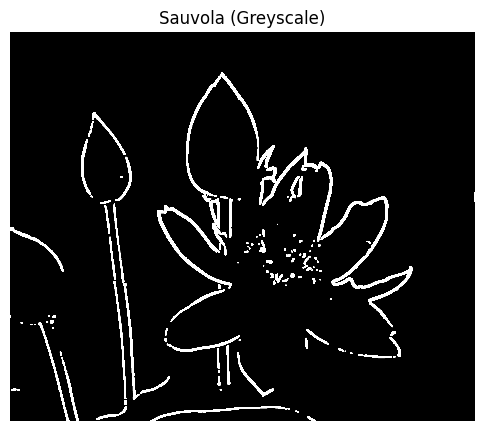

In [63]:
img_new = Sauvola(img)

plt.figure(figsize=(6, 6))
plt.imshow(img_new, cmap='gray', vmin=0, vmax=1)
plt.title(f"Sauvola (Greyscale)")
plt.axis('off')
plt.show()

In [70]:
multilevel(img_greyscale)

[13.9453125, 16.93359375, 23.90625, 39.84375, 44.82421875, 48.80859375, 66.73828125, 74.70703125, 76.69921875, 80.68359375, 82.67578125, 85.6640625, 87.65625, 100.60546875, 108.57421875, 115.546875, 120.52734375, 126.50390625, 144.43359375, 146.42578125, 150.41015625, 156.38671875, 158.37890625, 162.36328125, 164.35546875, 166.34765625, 173.3203125, 178.30078125, 185.2734375, 205.1953125, 207.1875, 215.15625, 217.1484375, 222.12890625, 226.11328125, 232.08984375, 234.08203125, 242.05078125]


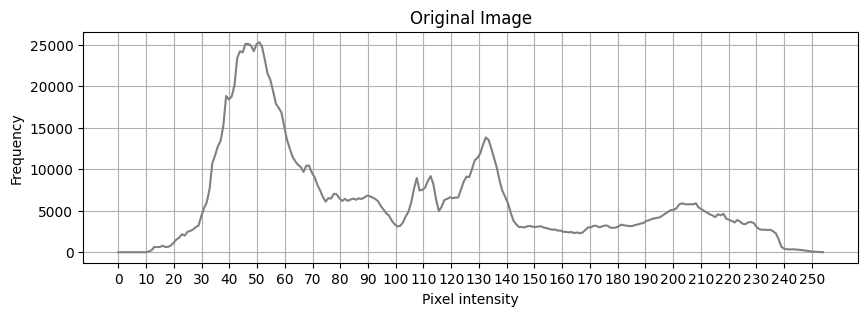

In [73]:
hist, bins = np.histogram(img_greyscale.ravel(), bins=256, range=(0, 255))

# Plot as a line instead of bars
plt.figure(figsize=(10, 3))
plt.plot(bins[:-1], hist, color='gray')
plt.title("Original Image")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")

plt.xticks(np.arange(0, 256, 10))  
plt.grid()
plt.show()

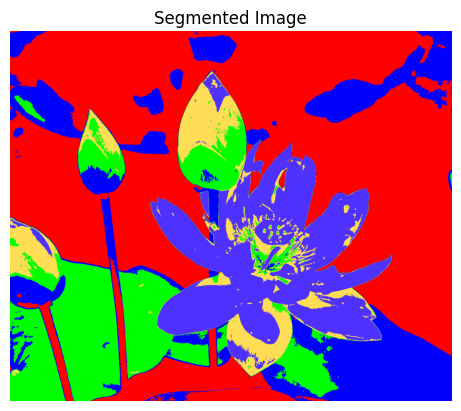

In [78]:
region1 = img_greyscale < 81
region2 = (img_greyscale >= 81) & (img_greyscale < 121)
region3 = (img_greyscale >= 121) & (img_greyscale < 150)
region4 = (img_greyscale >= 150) & (img_greyscale < 185)
region5 = img_greyscale >= 185


h, w = img_greyscale.shape
segmented = np.zeros((h, w, 3), dtype=np.uint8)

segmented[region1] = (255, 0, 0)  
segmented[region2] = (0, 0, 255)     
segmented[region3] = (0, 255, 0)    
segmented[region4] = (255, 221, 84)   
segmented[region5] = (78, 48, 255)

plt.imshow(segmented)
plt.title("Segmented Image")
plt.axis("off")
plt.show()

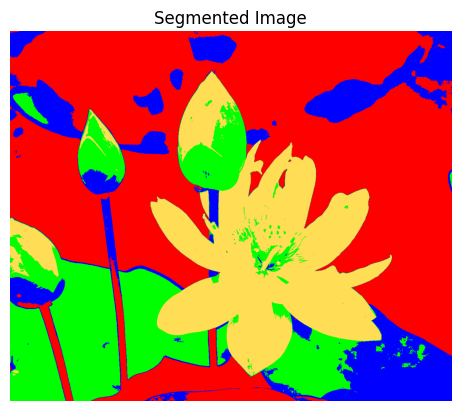

In [77]:
region1 = img_greyscale < 81
region2 = (img_greyscale >= 81) & (img_greyscale < 115)
region3 = (img_greyscale >= 115) & (img_greyscale < 156)
region4 = img_greyscale >= 156


h, w = img_greyscale.shape
segmented = np.zeros((h, w, 3), dtype=np.uint8)

segmented[region1] = (255, 0, 0)  
segmented[region2] = (0, 0, 255)     
segmented[region3] = (0, 255, 0)    
segmented[region4] = (255, 221, 84)   

plt.imshow(segmented)
plt.title("Segmented Image")
plt.axis("off")
plt.show()

In [ ]:
img_new = adaptive_gaussian(img_greyscale)

plt.figure(figsize=(6, 6))
plt.imshow(img_new, cmap='gray', vmin=0, vmax=1)
plt.title(f"Local Adaptive Threshold")
plt.axis('off')
plt.show()